In [1]:
import sys
from pathlib import Path
import pandas as pd
from sklearn.model_selection import GridSearchCV,train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
import numpy as np  

In [2]:
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT)) 

In [3]:
from src.data_loader import load_preprocessed_train,load_preprocessed_test
df_train=load_preprocessed_train()
df_test=load_preprocessed_test()

In [4]:
df_train.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,C,S,Q,Female,Male
0,1,0,3,22.0,1,0,7.2500,0.0,0.0,1.0,0.0,1.0
1,2,1,1,38.0,1,0,71.2833,1.0,0.0,0.0,1.0,0.0
2,3,1,3,26.0,0,0,7.9250,0.0,0.0,1.0,1.0,0.0
3,4,1,1,35.0,1,0,53.1000,0.0,0.0,1.0,1.0,0.0
4,5,0,3,35.0,0,0,8.0500,0.0,0.0,1.0,0.0,1.0


In [5]:
df_test.head()

,PassengerId,Pclass,Age,SibSp,Parch,Fare,C,S,Q,Female,Male
0,892,3,34.5,0,0,7.8292,0.0,1.0,0.0,0.0,1.0
1,893,3,47.0,1,0,7.0000,0.0,0.0,1.0,1.0,0.0
2,894,2,62.0,0,0,9.6875,0.0,1.0,0.0,0.0,1.0
3,895,3,27.0,0,0,8.6625,0.0,0.0,1.0,0.0,1.0
4,896,3,22.0,1,1,12.2875,0.0,0.0,1.0,1.0,0.0


<Axes: >

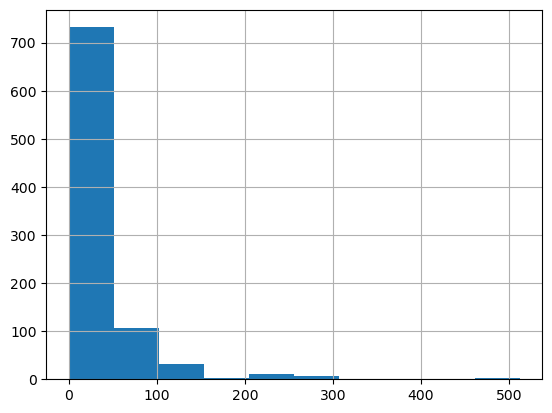

In [6]:
df_train['Fare'].hist()

In [ ]:
from src.train import split_data,standardisation
x_train,x_test,y_train,y_test=split_data(df_train)

In [9]:
x_train

,PassengerId,Pclass,Age,SibSp,Parch,Fare,C,S,Q,Female,Male
709,710,3,29.699118,1,1,15.2458,1.0,0.0,0.0,0.0,1.0
439,440,2,31.000000,0,0,10.5000,0.0,0.0,1.0,0.0,1.0
840,841,3,20.000000,0,0,7.9250,0.0,0.0,1.0,0.0,1.0
720,721,2,6.000000,0,1,33.0000,0.0,0.0,1.0,1.0,0.0
39,40,3,14.000000,1,0,11.2417,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
433,434,3,17.000000,0,0,7.1250,0.0,0.0,1.0,0.0,1.0
773,774,3,29.699118,0,0,7.2250,1.0,0.0,0.0,0.0,1.0
25,26,3,38.000000,1,5,31.3875,0.0,0.0,1.0,1.0,0.0
84,85,2,17.000000,0,0,10.5000,0.0,0.0,1.0,1.0,0.0


In [10]:

y_train

array([1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0,
       1, 1, 1])

In [11]:
x_test

,PassengerId,Pclass,Age,SibSp,Parch,Fare,C,S,Q,Female,Male
331,332,1,45.500000,0,0,28.5000,0.0,0.0,1.0,0.0,1.0
733,734,2,23.000000,0,0,13.0000,0.0,0.0,1.0,0.0,1.0
382,383,3,32.000000,0,0,7.9250,0.0,0.0,1.0,0.0,1.0
704,705,3,26.000000,1,0,7.8542,0.0,0.0,1.0,0.0,1.0
813,814,3,6.000000,4,2,31.2750,0.0,0.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
106,107,3,21.000000,0,0,7.6500,0.0,0.0,1.0,1.0,0.0
270,271,1,29.699118,0,0,31.0000,0.0,0.0,1.0,0.0,1.0
860,861,3,41.000000,2,0,14.1083,0.0,0.0,1.0,0.0,1.0
435,436,1,14.000000,1,2,120.0000,0.0,0.0,1.0,1.0,0.0


In [12]:
y_test

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0,
       1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1,
       1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0,
       1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1,
       0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0,

In [13]:
x_train_scaled,x_test_scaled=standardisation(x_train,x_test)

In [14]:
x_train_scaled

array([[ 1.05110212,  0.88742288, -0.04918352, ..., -1.40830868,
        -0.79200551,  0.79200551],
       [ 0.01112494, -0.25537349,  0.05079242, ...,  0.7100716 ,
        -0.79200551,  0.79200551],
       [ 1.55568365,  0.88742288, -0.79458411, ...,  0.7100716 ,
        -0.79200551,  0.79200551],
       ...,
       [-1.58350675,  0.88742288,  0.58875931, ...,  0.7100716 ,
         1.26261748, -1.26261748],
       [-1.35625248, -0.25537349, -1.02514134, ...,  0.7100716 ,
         1.26261748, -1.26261748],
       [-1.64128326,  0.88742288, -2.0242227 , ...,  0.7100716 ,
         1.26261748, -1.26261748]])

In [15]:
x_test_scaled

array([[-0.40486594, -1.39816986,  1.1651524 , ...,  0.7100716 ,
        -0.79200551,  0.79200551],
       [ 1.14354454, -0.25537349, -0.56402687, ...,  0.7100716 ,
        -0.79200551,  0.79200551],
       [-0.2084258 ,  0.88742288,  0.12764484, ...,  0.7100716 ,
        -0.79200551,  0.79200551],
       ...,
       [ 1.632719  ,  0.88742288,  0.81931654, ...,  0.7100716 ,
        -0.79200551,  0.79200551],
       [-0.00428213, -1.39816986, -1.25569858, ...,  0.7100716 ,
         1.26261748, -1.26261748],
       [-1.28692066, -1.39816986, -0.7177317 , ...,  0.7100716 ,
        -0.79200551,  0.79200551]])